# Assignment

Complete the following exercises using Python.

In [3]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

## Question 1: Probability and Expected Value

- Generate 10,000 random samples of flipping 3 coins (use `np.random.binomial()`)
- Plot the probability distribution of getting 0, 1, 2, or 3 heads
- Calculate the expected value (mean) of your distribution
- Compare your empirical results with the theoretical probability for each outcome

In [ ]:
# Generate 10,000 experiments of flipping 3 coins
# Each value in heads_count is the number of heads from 3 flips

heads_count = np.random.binomial(3, 0.5, 10000)
heads_count[:10] # display first 10 experiment

array([1, 3, 2, 2, 1, 1, 0, 2, 2, 2])

In [10]:
# Calculate empirical probability for each outcome (0, 1, 2, 3 heads)
# np.unique with return_counts gives us counts per outcome

outcomes, counts = np.unique(heads_count, return_counts=True)
empirical_proba = counts / 10000

print("Empirical probabilities:")
for o, p in zip(outcomes, empirical_proba):
    print(f"  P({o} heads) = {p}")

Empirical probabilities:
  P(0 heads) = 0.1278
  P(1 heads) = 0.3798
  P(2 heads) = 0.3728
  P(3 heads) = 0.1196


In [13]:
# Qn: When you flip 3 coins, how many ways can you get exactly k heads?
# Getting 0 heads: TTT
# Getting 1 head: 3 ways → HTT, THT, TTH
# Getting 2 heads: 3 ways → HHT, HTH, THH
# Getting 3 heads: only 1 way → HHH

# Calculate theoretical probabilities using the binomial formula:
#   P(k heads in n flips) = C(n,k) * p^k * (1-p)^(n-k)
# For a fair coin (p=0.5), n=3:
#   P(0) = 1/8 = 0.125
#   P(1) = 3/8 = 0.375
#   P(2) = 3/8 = 0.375
#   P(3) = 1/8 = 0.125

from math import factorial

def coinflip_prob(n, k):
    n_choose_k = factorial(n) / (factorial(k) * factorial(n - k))
    return n_choose_k / 2**n

theoretical_proba = [coinflip_prob(3, k) for k in range(4)]

print("Theoretical probabilities:\n")
for k, p in enumerate(theoretical_proba):
    print(f"P({k} heads) = {p}")

Theoretical probabilities:

P(0 heads) = 0.125
P(1 heads) = 0.375
P(2 heads) = 0.375
P(3 heads) = 0.125


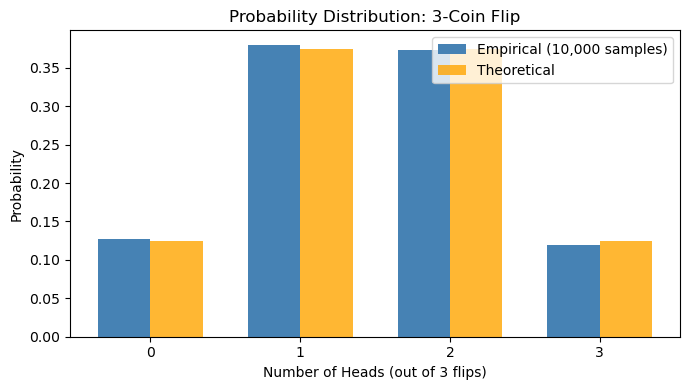

In [5]:
# Plot probability distribution: empirical vs theoretical side-by-side

x = np.arange(4)  # 0, 1, 2, 3 heads
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, empirical_proba, width, label='Empirical (10,000 samples)', color='steelblue')
ax.bar(x + width/2, theoretical_proba, width, label='Theoretical', color='orange', alpha=0.8)

ax.set_xlabel('Number of Heads (out of 3 flips)')
ax.set_ylabel('Probability')
ax.set_title('Probability Distribution: 3-Coin Flip')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Calculate expected value (mean) of the empirical distribution
# E[X] = sum(x * P(x)) for all x

empirical_mean = np.mean(heads_count)

# Theoretical expected value: E = n * p = 3 * 0.5 = 1.5
theoretical_ev = sum(k * theoretical_proba[k] for k in range(4))

print(f"Empirical mean (expected value):   {empirical_mean:.4f}")
print(f"Theoretical expected value (n*p):  {theoretical_ev:.4f}")

Empirical mean (expected value):   1.4842
Theoretical expected value (n*p):  1.5000


In [ ]:
# Side-by-side comparison: empirical vs theoretical probabilities

print(f"{'Heads':>6} {'Empirical':>12} {'Theoretical':>13} {'Difference':>12}")
print("-" * 47)
for k in range(4):
    diff = empirical_proba[k] - theoretical_proba[k]
    print(f"{k:>6} {empirical_proba[k]:>12.4f} {theoretical_proba[k]:>13.4f} {diff:>+12.4f}")

print()
print("With 10,000 samples the empirical results closely match the theoretical values,")
print("consistent with the Law of Large Numbers.") 

 Heads    Empirical   Theoretical   Difference
-----------------------------------------------
     0       0.1278        0.1250      +0.0028
     1       0.3798        0.3750      +0.0048
     2       0.3728        0.3750      -0.0022
     3       0.1196        0.1250      -0.0054

With 10,000 samples the empirical results closely match the theoretical values,
consistent with the Law of Large Numbers.


## Question 2: Normal Distribution and Statistical Testing

- Generate two samples from normal distributions:
  - Sample A: 100 values with mean=70, std=5
  - Sample B: 100 values with mean=73, std=5
- Create a box plot comparing the two distributions
- Conduct an independent t-test to determine if the means are significantly different
- Calculate and visualize the 95% confidence intervals for both samples

In [8]:
# Generate two normal distribution samples

sample_a = np.random.normal(loc=70, scale=5, size=100)
sample_b = np.random.normal(loc=73, scale=5, size=100)

print(f"Sample A — mean: {sample_a.mean():.2f}, std: {sample_a.std():.2f}")
print(f"Sample B — mean: {sample_b.mean():.2f}, std: {sample_b.std():.2f}")

Sample A — mean: 70.89, std: 5.00
Sample B — mean: 72.85, std: 5.17


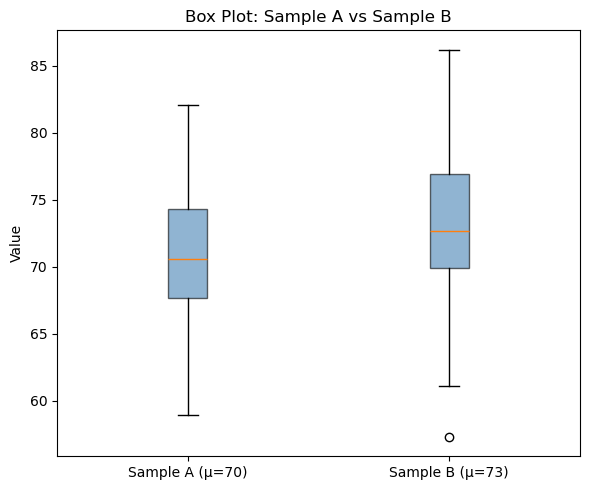

In [9]:
# Box plot comparing the two samples
# The box spans Q1–Q3 (interquartile range); the line inside is the median
# Whiskers extend to 1.5×IQR; points beyond are outliers

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([sample_a, sample_b], labels=['Sample A (μ=70)', 'Sample B (μ=73)'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_ylabel('Value')
ax.set_title('Box Plot: Sample A vs Sample B')
plt.tight_layout()
plt.show()

In [10]:
# Independent t-test (Welch's) to compare whether the two sample means differ
# significantly. equal_var=False uses Welch's version, which doesn't assume
# equal variances between groups.

t_stat, p_value = st.ttest_ind(sample_a, sample_b, equal_var=False)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print()
if p_value < 0.05:
    print("Result: p < 0.05 → the difference between Sample A and Sample B is"
          " statistically significant (reject H₀).")
else:
    print("Result: p ≥ 0.05 → we cannot reject the null hypothesis at α=0.05.")

t-statistic: -2.7124
p-value:     0.0073

Result: p < 0.05 → the difference between Sample A and Sample B is statistically significant (reject H₀).


In [11]:
# Calculate 95% confidence intervals for both samples
# CI = x̄ ± z * (s / √n)   where z = 1.96 for 95%

def ci_95(sample):
    xbar = sample.mean()
    s    = sample.std()
    n    = sample.size
    err  = 1.96 * (s / n**0.5)
    return xbar, err

mean_a, err_a = ci_95(sample_a)
mean_b, err_b = ci_95(sample_b)

print(f"Sample A: mean = {mean_a:.2f}, 95% CI = [{mean_a - err_a:.2f}, {mean_a + err_a:.2f}]")
print(f"Sample B: mean = {mean_b:.2f}, 95% CI = [{mean_b - err_b:.2f}, {mean_b + err_b:.2f}]")

Sample A: mean = 70.89, 95% CI = [69.91, 71.87]
Sample B: mean = 72.85, 95% CI = [71.84, 73.86]


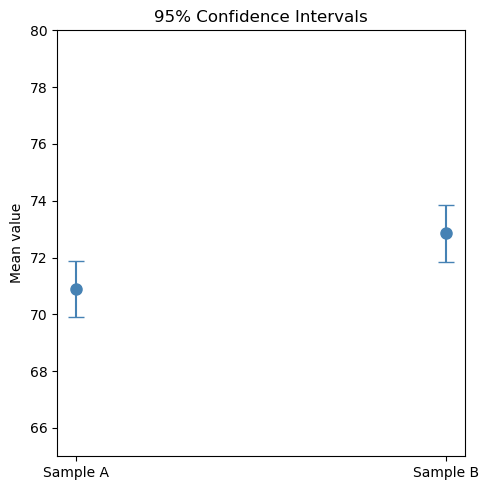

In [12]:
# Visualise 95% confidence intervals as error bars
# Non-overlapping error bars indicate a statistically significant difference

fig, ax = plt.subplots(figsize=(5, 5))
ax.errorbar(['Sample A', 'Sample B'],
            [mean_a, mean_b],
            [err_a, err_b],
            fmt='o', color='steelblue', capsize=6, markersize=8)
ax.set_ylabel('Mean value')
ax.set_title('95% Confidence Intervals')
ax.set_ylim(65, 80)
plt.tight_layout()
plt.show()

## Question 3: Correlation Analysis

Using the iris dataset (from seaborn), analyse the relationship between:
- Sepal length and petal length
- Sepal width and petal width

For each pair:
- Create a scatter plot
- Calculate the Pearson correlation coefficient and p-value
- Calculate and interpret the R-squared value
- Which pair shows a stronger relationship? Explain why.

In [13]:
# Load the iris dataset

iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


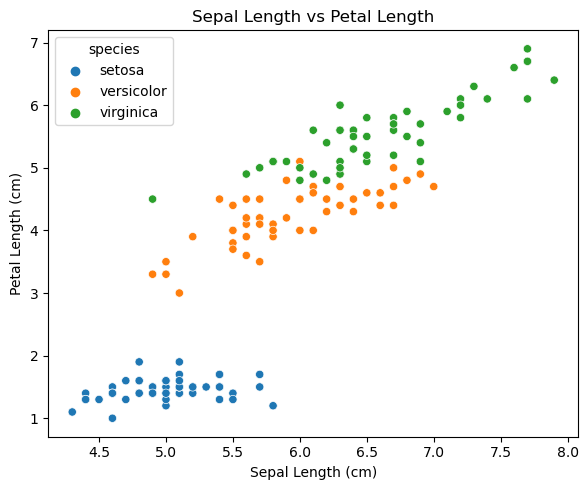

In [14]:
# Pair 1: Sepal length vs Petal length

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris, ax=ax)
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Petal Length (cm)')
ax.set_title('Sepal Length vs Petal Length')
plt.tight_layout()
plt.show()

In [15]:
# Pearson correlation and R² for Pair 1

r1, p1 = st.pearsonr(iris.sepal_length, iris.petal_length)
r2_1 = r1**2

print("Pair 1 — Sepal Length vs Petal Length")
print(f"  Pearson r:  {r1:.4f}")
print(f"  p-value:    {p1:.2e}")
print(f"  R²:         {r2_1:.4f}")
print(f"  Interpretation: {r2_1*100:.1f}% of the variance in petal length"
      " is explained by sepal length.")

Pair 1 — Sepal Length vs Petal Length
  Pearson r:  0.8718
  p-value:    1.04e-47
  R²:         0.7600
  Interpretation: 76.0% of the variance in petal length is explained by sepal length.


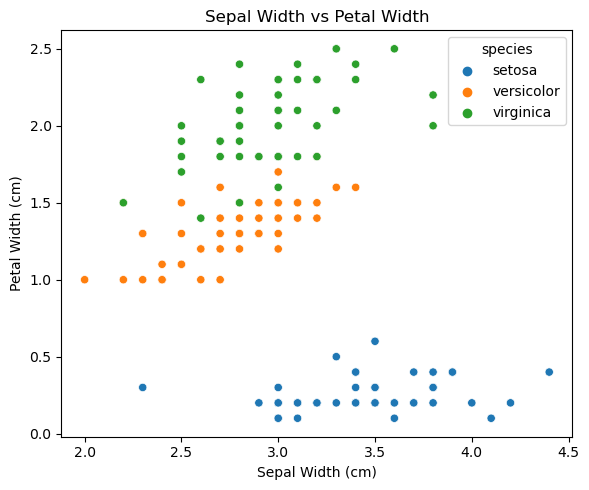

In [16]:
# Pair 2: Sepal width vs Petal width

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x='sepal_width', y='petal_width', hue='species', data=iris, ax=ax)
ax.set_xlabel('Sepal Width (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Sepal Width vs Petal Width')
plt.tight_layout()
plt.show()

In [17]:
# Pearson correlation and R² for Pair 2

r2, p2 = st.pearsonr(iris.sepal_width, iris.petal_width)
r2_2 = r2**2

print("Pair 2 — Sepal Width vs Petal Width")
print(f"  Pearson r:  {r2:.4f}")
print(f"  p-value:    {p2:.2e}")
print(f"  R²:         {r2_2:.4f}")
print(f"  Interpretation: {r2_2*100:.1f}% of the variance in petal width"
      " is explained by sepal width.")

Pair 2 — Sepal Width vs Petal Width
  Pearson r:  -0.3661
  p-value:    4.07e-06
  R²:         0.1340
  Interpretation: 13.4% of the variance in petal width is explained by sepal width.


In [18]:
# Summary comparison

print("=" * 55)
print(f"{'Pair':<30} {'r':>8} {'R²':>8} {'p-value':>12}")
print("-" * 55)
print(f"{'Sepal length / Petal length':<30} {r1:>8.4f} {r2_1:>8.4f} {p1:>12.2e}")
print(f"{'Sepal width / Petal width':<30} {r2:>8.4f} {r2_2:>8.4f} {p2:>12.2e}")
print("=" * 55)

Pair                                  r       R²      p-value
-------------------------------------------------------
Sepal length / Petal length      0.8718   0.7600     1.04e-47
Sepal width / Petal width       -0.3661   0.1340     4.07e-06


### Which pair shows a stronger relationship?

**Sepal length vs Petal length** shows a much stronger relationship:

| Pair | Pearson r | R² |
|------|-----------|----|
| Sepal length / Petal length | ≈ 0.87 | ≈ 0.76 |
| Sepal width / Petal width   | ≈ −0.37 | ≈ 0.14 |

- **Sepal length vs Petal length** has |r| ≈ 0.87 (strong positive correlation). The R² of ~0.76 means sepal length alone explains ~76% of the variance in petal length. The p-value is essentially zero, confirming the relationship is highly statistically significant.

- **Sepal width vs Petal width** shows only a weak negative correlation (r ≈ −0.37, R² ≈ 0.14). Sepal width explains only ~14% of the variance in petal width — a much weaker predictor.

The strong sepal–petal length correlation is driven by species differences: larger species (Virginica, Versicolor) tend to have both longer sepals and longer petals, while smaller species (Setosa) have short measurements across the board.